# Visualizing categorical data

In the [relational plot tutorial](./10_relplot.ipynb) we saw how to use different visual representations to show the relationship between multiple variables in a dataset. In the examples, we focused on cases where the main relationship was between two numerical variables. **If one of the main variables is “categorical” (divided into discrete groups) it may be helpful to use a more specialized approach to visualization**.

It’s helpful to think of the different categorical plot kinds as belonging to **three different families**, which we’ll discuss in detail below. They are:

1. **Categorical scatterplots**:
   - [`stripplot()`](https://seaborn.pydata.org/generated/seaborn.stripplot.html#seaborn.stripplot) (with `kind="strip"`; the default)
   - [`swarmplot()`](https://seaborn.pydata.org/generated/seaborn.swarmplot.html#seaborn.swarmplot) (with `kind="swarm"`)
2. **Categorical distribution plots**:
   - [`boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot) (with `kind="box"`)
   - [`boxenplot()`](https://seaborn.pydata.org/generated/seaborn.boxenplot.html#seaborn.boxenplot) (with `kind="boxen"`)
   - [`violinplot()`](https://seaborn.pydata.org/generated/seaborn.violinplot.html#seaborn.violinplot) (with `kind="violin"`)
3. **Categorical estimate plots**:
   - [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn.countplot) (with `kind="count"`)
   - [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html#seaborn.barplot) (with `kind="bar"`)
   - [`pointplot()`](https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot) (with `kind="point"`)

The unified API [`catplot()`](https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot) makes it easy to switch between different kinds and see your data from several perspectives.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Categorical scatterplots

The default representation of the data in `catplot()` uses a scatterplot. There are actually two different categorical scatter plots in seaborn. They take different approaches to resolving the main challenge in representing categorical data with a scatter plot, which is that all of the points belonging to one category would fall on the same position along the axis corresponding to the categorical variable. The approach used by `stripplot()`, which is the default “kind” in `catplot()` is to adjust the positions of points on the categorical axis with a small amount of random “jitter”:

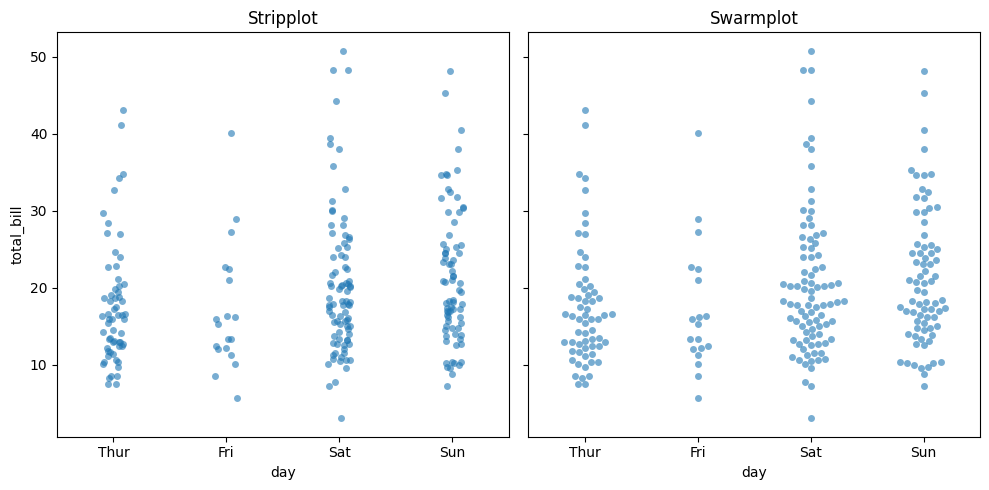

In [14]:
# Stripplot and swarmplot are axes-level functions, so use them directly (not catplot) for subplotting
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    sharey=True
)

sns.stripplot(data=tips, x="day", y="total_bill", ax=axes[0], alpha=0.6)
axes[0].set_title("Stripplot")

sns.swarmplot(data=tips, x="day", y="total_bill", ax=axes[1], alpha=0.6)
axes[1].set_title("Swarmplot")

plt.tight_layout()
plt.show()

Similar to the relational plots, it’s possible to add another dimension to a categorical plot by using a `hue` semantic. (The categorical plots **do not** currently support `size` or `style` semantics). Each different categorical plotting function handles the `hue` semantic differently. For the scatter plots, it is only necessary to change the color of the points:

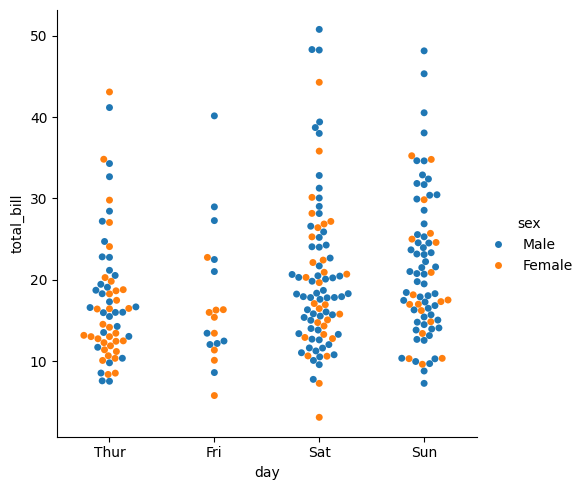

In [15]:
sns.catplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    kind="swarm"
)

The **ordering can also be controlled** on a plot-specific basis using the order parameter. This can be important when drawing multiple categorical plots in the same figure, which we’ll see more of below:

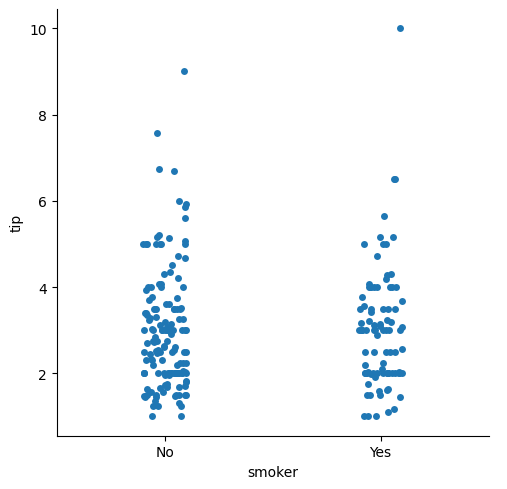

In [19]:
sns.catplot(
    data=tips,
    x="smoker",
    y="tip",
    order=["No", "Yes"],
)

it’s often helpful to put the categorical variable **on the vertical axis** instead, specifically, when:

1. the category **names are relatively long**
2. or **there are many categories**

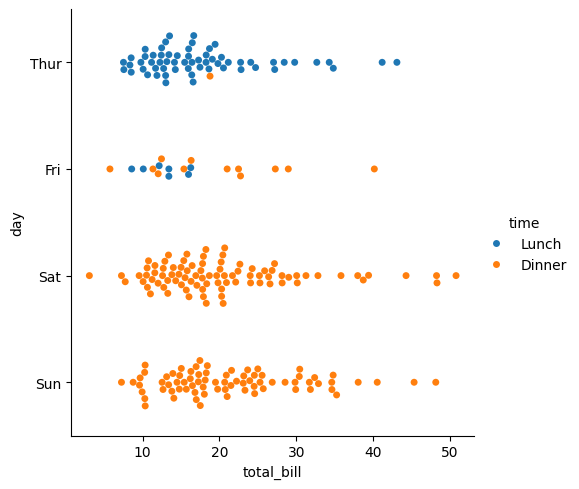

In [20]:
sns.catplot(
    data=tips,
    x="total_bill",
    y="day",
    hue="time",
    kind="swarm"
)

## Comparing distributions

**As the size of the dataset grows**, categorical scatter plots become limited in the information they can provide about the distribution of values within each category. When this happens, there are several approaches for summarizing the distributional information in ways that facilitate easy comparisons across the category levels.

### Boxplots

The first is the familiar [`boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot "seaborn.boxplot"). This kind of plot shows the three quartile values of the distribution along with extreme values. The “whiskers” extend to points that lie within 1.5 IQRs of the lower and upper quartile, and then observations that fall outside this range are displayed independently. This means that each value in the boxplot corresponds to an actual observation in the data.

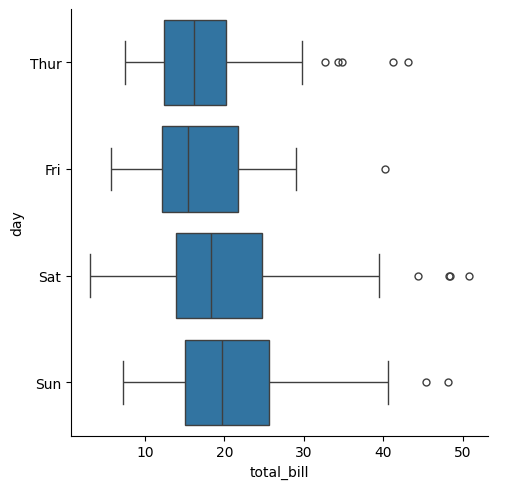

In [25]:
sns.catplot(
    data=tips,
    y="day",
    x="total_bill",
    kind="box" # ADDED
)

For further customization of the plot, you can use the methods on the FacetGrid object that it returns:

In [38]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


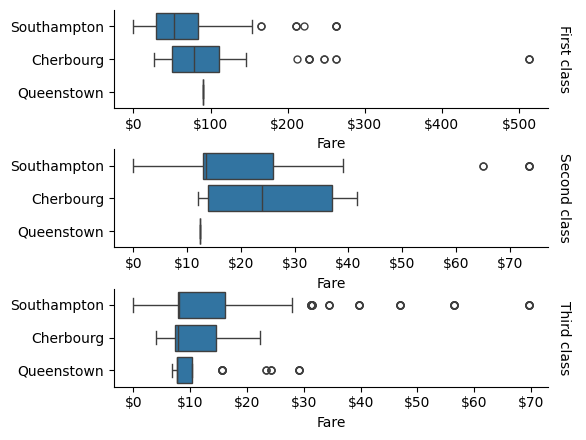

In [65]:
g = sns.catplot(
    data=titanic,
    x="fare",
    y="embark_town",
    row="class",
    kind="box",
    orient="h",
    sharex=False,
    margin_titles=True,
    height=1.5, aspect=4,
)
g.set(xlabel="Fare", ylabel="")
g.set_titles(row_template="{row_name} class")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter('${x:.0f}')

Notice the x-axis is different for all three plots since we specified `sharex=False`.

### Boxen plot

A related function, [`boxenplot()`](https://seaborn.pydata.org/generated/seaborn.boxenplot.html#seaborn.boxenplot "seaborn.boxenplot"), draws a plot that is similar to a box plot but optimized for showing more information about the shape of the distribution. **It is best suited for larger datasets**:

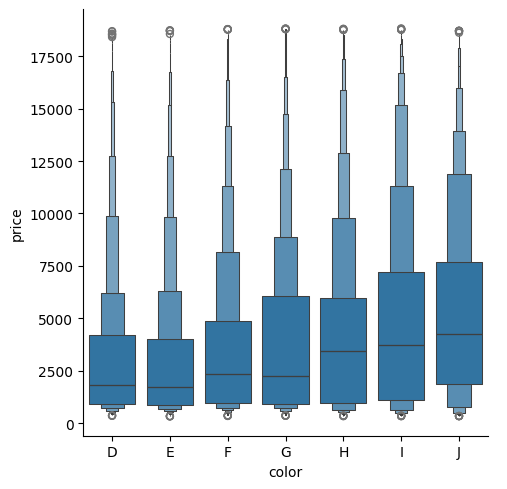

In [ ]:
diamonds = sns.load_dataset("diamonds")
sns.catplot(
    data=diamonds.sort_values("color"),
    x="color", y="price", kind="boxen",
)

### Violin plots

A different approach is a [`violinplot()`](https://seaborn.pydata.org/generated/seaborn.violinplot.html#seaborn.violinplot "seaborn.violinplot"), which combines a **boxplot** with the **kernel density estimation** procedure described in the [distributions](https://seaborn.pydata.org/tutorial/distributions.html#distribution-tutorial) tutorial:

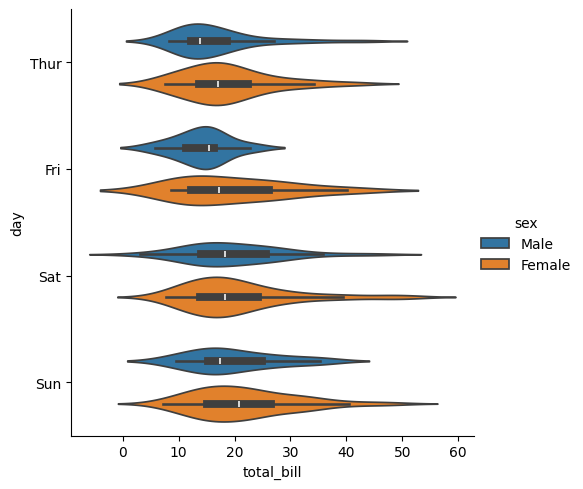

In [45]:
sns.catplot(
    data=tips,
    x="total_bill",
    y="day",
    hue="sex",
    kind="violin",
)

It’s also possible to **“split” the violins**, which can allow for a more efficient use of space:

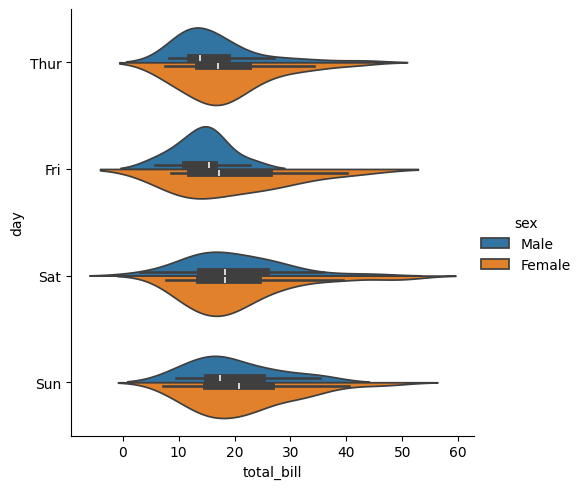

In [46]:
sns.catplot(
    data=tips,
    x="total_bill",
    y="day",
    hue="sex",
    kind="violin",
    split=True,
)

Finally, there are several options for the plot that is drawn on the interior of the violins, including ways to **show each individual observation** instead of the summary boxplot values:

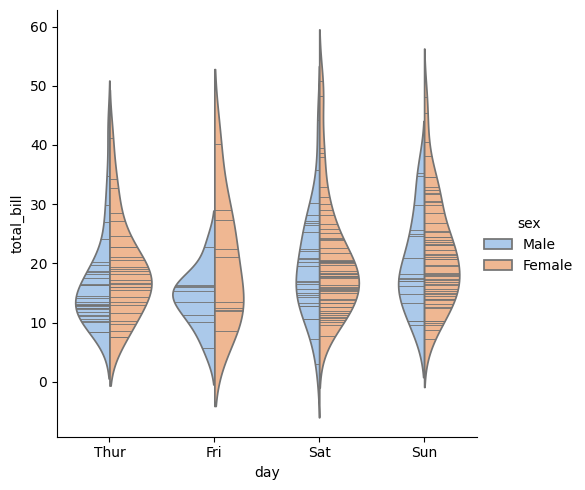

In [47]:
sns.catplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    kind="violin",
    inner="stick",
    split=True,
    palette="pastel",
)

It can also be useful to combine [`swarmplot()`](https://seaborn.pydata.org/generated/seaborn.swarmplot.html#seaborn.swarmplot "seaborn.swarmplot") or [`stripplot()`](https://seaborn.pydata.org/generated/seaborn.stripplot.html#seaborn.stripplot "seaborn.stripplot") with a box plot or violin plot to show each observation along with a summary of the distribution:

<Axes: xlabel='day', ylabel='total_bill'>

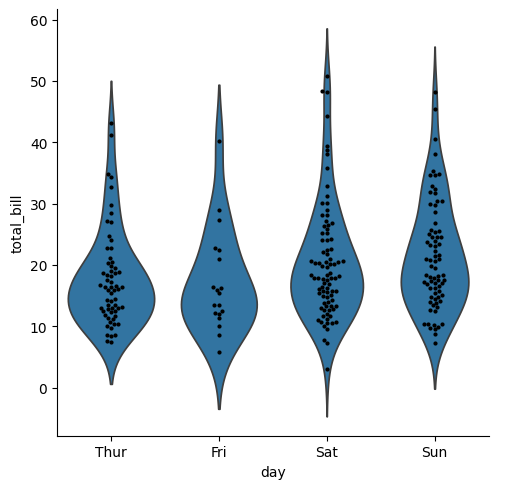

In [54]:
g = sns.catplot(
    data=tips, 
    x="day", 
    y="total_bill", 
    kind="violin", 
    inner=None)

sns.swarmplot(
    data=tips, 
    x="day", 
    y="total_bill", 
    color="k", 
    size=3, 
    ax=g.ax)

## Count Plot

In seaborn, the [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn.countplot) function is **similar to a histogram over a categorical, rather than quantitative, variable**. Notice that we neve specify the y-axis, because it is implicitly the `count`:

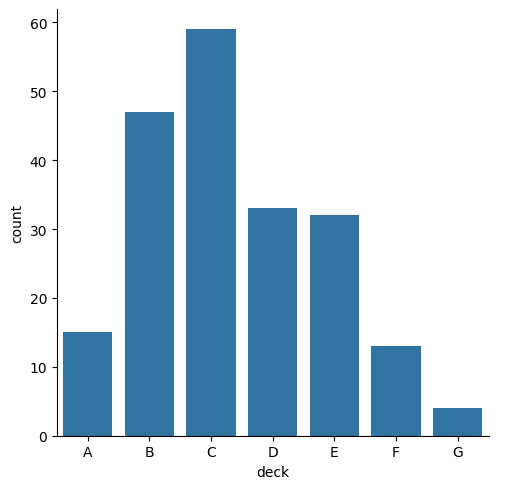

In [69]:
sns.catplot(data=titanic, x="deck", kind="count")

## Estimating central tendency

For other applications, rather than showing the distribution within each category, you might want to show **an estimate of the central tendency of the values**.

### Bar plots

**Not to be confused with the** [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn.countplot), the [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html#seaborn.barplot) function:

- operates on a full dataset and applies a function to **obtain the estimate (taking the mean by default)**.
- When there are multiple observations in each category, it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using [error bars](https://seaborn.pydata.org/tutorial/error_bars.html):

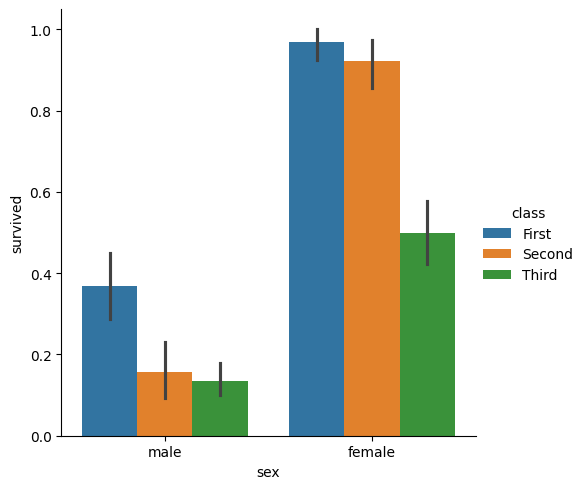

In [67]:
titanic = sns.load_dataset("titanic")
sns.catplot(
    data=titanic, x="sex", y="survived", hue="class",
    kind="bar")

The default error bars show 95% confidence intervals, but (starting in v0.12), it is possible to select from a number of other representations:

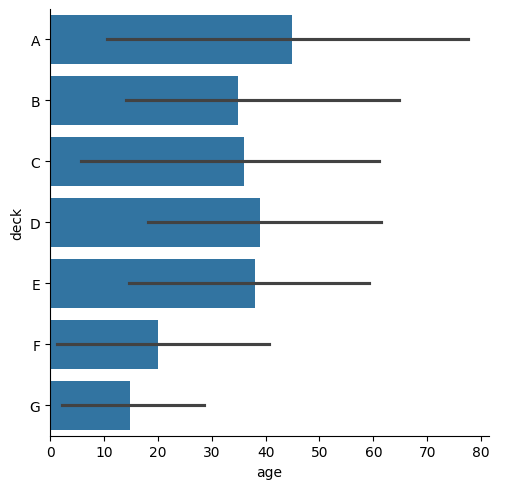

In [68]:
sns.catplot(
    data=titanic, x="age", y="deck",
    errorbar=("pi", 95), kind="bar"
)

### Point plots

An alternative style for visualizing the same information is offered by the [`pointplot()`](https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot "seaborn.pointplot") function. This function:

1. also encodes the value of the estimate with height on the other axis, **but rather than showing a full bar, it plots the point estimate and confidence interval**.
2. Additionally, [`pointplot()`](https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot "seaborn.pointplot") connects points from the same `hue` category. This makes it easy to see how the main relationship is changing as a function of the hue semantic, **because your eyes are quite good at picking up on differences of slopes**
3. It can still be a good idea to vary the `marker` and/or linestyle along with the `hue` to make figures that are maximally accessible and reproduce well in black and white:

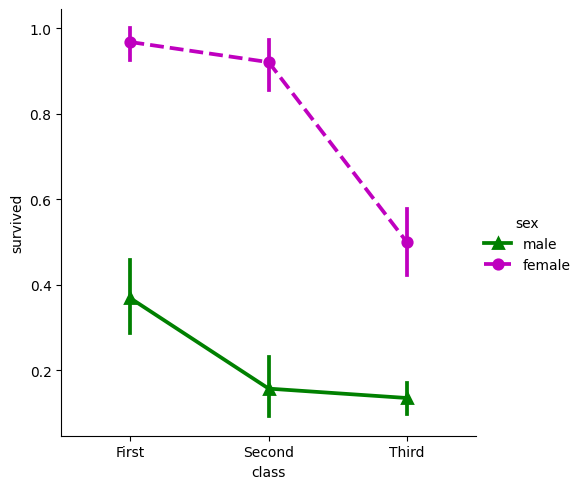

In [71]:
sns.catplot(
    data=titanic, x="class", y="survived", hue="sex",
    palette={"male": "g", "female": "m"},
    markers=["^", "o"], linestyles=["-", "--"],
    kind="point"
)